In [1]:
# One hot encoding

import numpy as np
def one_hot_encoding(sentence):
    words = sentence.lower().split()
    vocabulary = sorted(set(words))
    word_to_idx = {word: i for i, word in enumerate(vocabulary)}
    one_hot_matrix = np.zeros((len(words), len(vocabulary)))
    for i, word in enumerate(words):
        one_hot_matrix[i, word_to_idx[word]] = 1
    return one_hot_matrix, vocabulary

In [2]:
sentence = "Should we go to a pizzeria or do you prefer a restaurant?"
one_hot_matrix, vocabulary = one_hot_encoding(sentence)
print("Vocabulary:", vocabulary)
print("One-Hot Encoding Matrix:\n", one_hot_matrix)

Vocabulary: ['a', 'do', 'go', 'or', 'pizzeria', 'prefer', 'restaurant?', 'should', 'to', 'we', 'you']
One-Hot Encoding Matrix:
 [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [3]:
# Bag of Words
# - Tokenize each document to get a list of words
# - Create a vocab of unique words and map each to the corresponding index of the vocab
# - Create a matrix where each row represents a document and each column, instead, a word in the vocabulary

In [4]:
def bag_of_words(sentences):
    tokenized_sentences = [sentence.lower().split() for sentence in sentences]
    flat_words = [word for sublist in tokenized_sentences for word in sublist]
    vocabulary = sorted(set(flat_words))
    word_to_idx = {word: i for i, word in enumerate(vocabulary)}
    bow_matrix = np.zeros((len(sentences), len(vocabulary)), dtype=int)
    for i, sentence in enumerate(tokenized_sentences):
        for word in sentence:
            if word in word_to_idx:
                bow_matrix[i, word_to_idx[word]] += 1
    return vocabulary, bow_matrix


In [5]:
corpus = ["This movie is awesome awesome",
          "I do not say is good, but neither awesome",
          "Awesome? Only a fool can say that"]
vocabulary, bow_matrix = bag_of_words(corpus)
print("Vocabulary:", vocabulary)
print("Bag of Words Matrix:\n", bow_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
Bag of Words Matrix:
 [[0 2 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0]]


In [6]:
len(vocabulary)

17

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
def bag_of_words(sentences):
    vectorizer = CountVectorizer(tokenizer=lambda text: text.lower().split(), token_pattern=None)
    bow_matrix = vectorizer.fit_transform(sentences)
    return vectorizer.get_feature_names_out(), bow_matrix.toarray()

In [8]:
vocabulary, bow_matrix = bag_of_words(corpus)
print("Vocabulary:", vocabulary)
print("Bag of Words Matrix:\n", bow_matrix)

Vocabulary: ['a' 'awesome' 'awesome?' 'but' 'can' 'do' 'fool' 'good,' 'i' 'is' 'movie'
 'neither' 'not' 'only' 'say' 'that' 'this']
Bag of Words Matrix:
 [[0 2 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0]]


In [9]:
len(vocabulary)

17

In [10]:
# TF-IDF

# tf = num repeated words in sentence / num words in sentence
from collections import Counter


def compute_tf(sentences):
    tokenized_sentences = [s.lower().split() for s in sentences]
    vocabulary = sorted(set(word for sentence in tokenized_sentences for word in sentence))
    word_idx = {word: i for i, word in enumerate(vocabulary)}
    
    tf = np.zeros((len(sentences), len(vocabulary)))
    for i, words in enumerate(tokenized_sentences):
        word_counts = Counter(words)
        total_words = len(words)
        if total_words > 0:
            # Extract indices and counts for only the unique words present in this sentence
            indices = [word_idx[word] for word in word_counts]
            tf[i, indices] = [count / total_words for count in word_counts.values()]
            
    return tf, vocabulary

In [11]:
# IDF = ln(num_sentences / num_sentences containing words)
def compute_idf(sentences, vocabulary):
    num_documents = len(sentences)
    # Pre-tokenize sentences
    sentence_sets = [set(s.lower().split()) for s in sentences]
    # Allocated a 1D array for IDF (one value per word)
    idf = np.zeros(len(vocabulary))
    for idx, word in enumerate(vocabulary):
        df = sum(1 for s_set in sentence_sets if word in s_set)
        idf[idx] = np.log(num_documents / (1 + df))
    return idf

def tf_idf(sentences):
    tf, vocabulary = compute_tf(sentences)
    idf = compute_idf(sentences, vocabulary)
    tf_idf_matrix = tf * idf
    return vocabulary, tf_idf_matrix

In [12]:
vocabulary, tf_idf_matrix = tf_idf(corpus)
print("Vocabulary:", vocabulary)
print("TF-IDF Matrix:\n", tf_idf_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
TF-IDF Matrix:
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.08109302 0.
  0.         0.         0.         0.         0.08109302]
 [0.         0.         0.         0.04505168 0.         0.04505168
  0.         0.04505168 0.04505168 0.         0.         0.04505168
  0.04505168 0.         0.         0.         0.        ]
 [0.05792359 0.         0.05792359 0.         0.05792359 0.
  0.05792359 0.         0.         0.         0.         0.
  0.         0.05792359 0.         0.05792359 0.        ]]


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

corpus = ["i love natural language processing", "word2vec embeddings using pytorch"]
tokenized = [s.lower().split() for s in corpus]
vocab = sorted(list(set(w for s in tokenized for w in s)))
word_to_idx = {w: i for i, w in enumerate(vocab)}

window_size = 2 

targets, contexts = [], []
for s in tokenized:
    indices = [word_to_idx[w] for w in s]
    for i in range(len(indices)):
        start = max(0, i - window_size)
        end = min(len(indices), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                targets.append(indices[i])
                contexts.append(indices[j])
                
X = torch.tensor(targets, dtype=torch.long)
y = torch.tensor(contexts, dtype=torch.long)

class Word2Vec(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.network = nn.Sequential(nn.Embedding(vocab_size, dim), nn.Linear(dim, vocab_size, bias=False))
    def forward(self, x):
        return self.network(x)
    
model = Word2Vec(len(vocab), dim=10)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    
embeddings = model.network[0].weight.detach().numpy()
print("Word Vectors:\n", embeddings[word_to_idx['pytorch']])

Word Vectors:
 [ 2.0090725   0.9021343  -0.7099533   0.6701859   1.9723397   0.03453812
  1.604412    1.3509218  -1.5996422  -1.8399614 ]


In [14]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")

In [15]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split


df["sentiment_encoded"] = (df["sentiment"] != "positive").astype(np.int64)
X, y = df["review"].values, df["sentiment_encoded"].values

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.143, stratify=y_train, random_state=42
)


In [19]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

def generate_wordclouds(df):
    # Words only, drop single letters, no digits
    vectorizer = CountVectorizer(stop_words="english", token_pattern = r'(?u)\b[a-zA-Z]{2,}\b')
    def get_frequencies(reviews):
        if reviews.empty:
            return{}
        dtm = vectorizer.fit_transform(reviews)
        frequencies = dict(zip(vectorizer.get_feature_names_out(),dtm.sum(axis=0).A1))
        return frequencies
    
    # Process sentiments
    positive_counts = get_frequencies(df[df['sentiment'] == 'positive']['review'])
    negative_counts = get_frequencies(df[df['sentiment'] == 'negative']['review'])
    
    # Wordcloud
    positive_wordcloud = WordCloud(width = 400, height = 400, max_words=50,max_font_size=100, background_color="white", color_func=lambda *args, **kwargs: "green").generate_from_frequencies(positive_counts)
    negative_wordcloud = WordCloud(width = 400, height = 400, max_words=50,max_font_size=100, background_color="white", color_func=lambda *args, **kwargs: "red").generate_from_frequencies(negative_counts)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(positive_wordcloud, interpolation="bilinear")
    plt.title("Positive Reviews")
    plt.axis("off")
    
    # plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 2)
    plt.imshow(negative_wordcloud, interpolation="bilinear")
    plt.title("Negative Reviews")
    plt.axis("off")
    
    plt.savefig('word_clouds.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

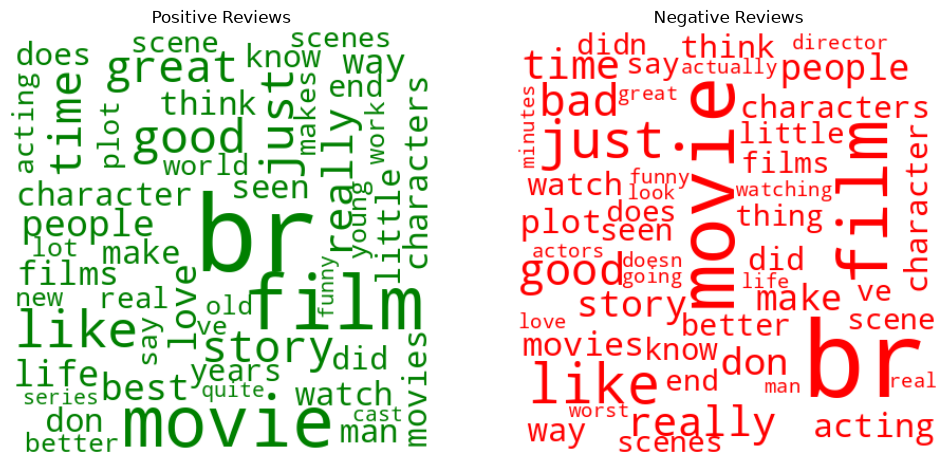

In [20]:
generate_wordclouds(df)

In [21]:
def plot_review_length_by_sentiment(df):
    df["word_count"] = df["review"].str.split().str.len()
    pos_lengths = df[df["sentiment"] == "positive"]["word_count"]
    neg_lengths = df[df["sentiment"] == "negative"]["word_count"]
    
    def get_stats_text(series):
        if series.empty:return "Empty"
        return f"Min: {series.min()}\nAvg: {series.mean():.2f}\nMedian: {series.median()}\nMax: {series.max()}"
    
    plt.figure(figsize=(12, 6))
    
    # Positive reviews
    plt.subplot(1, 2, 1)
    plt.hist(pos_lengths, bins=30, color="green", edgecolor="black", alpha=0.7)
    plt.title('Word Distribution for Positive Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    plt.text(0.95, 0.95, get_stats_text(pos_lengths), transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top', horizontalalignment='right', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))
    
    # Plot for negative reviews
    plt.subplot(1, 2, 2)
    plt.hist(neg_lengths, bins=30, color='red', edgecolor='black', alpha=0.7)
    plt.title('Word Distribution for Negative Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    plt.text(0.95, 0.95, get_stats_text(neg_lengths), transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top', horizontalalignment='right', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('review_length.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

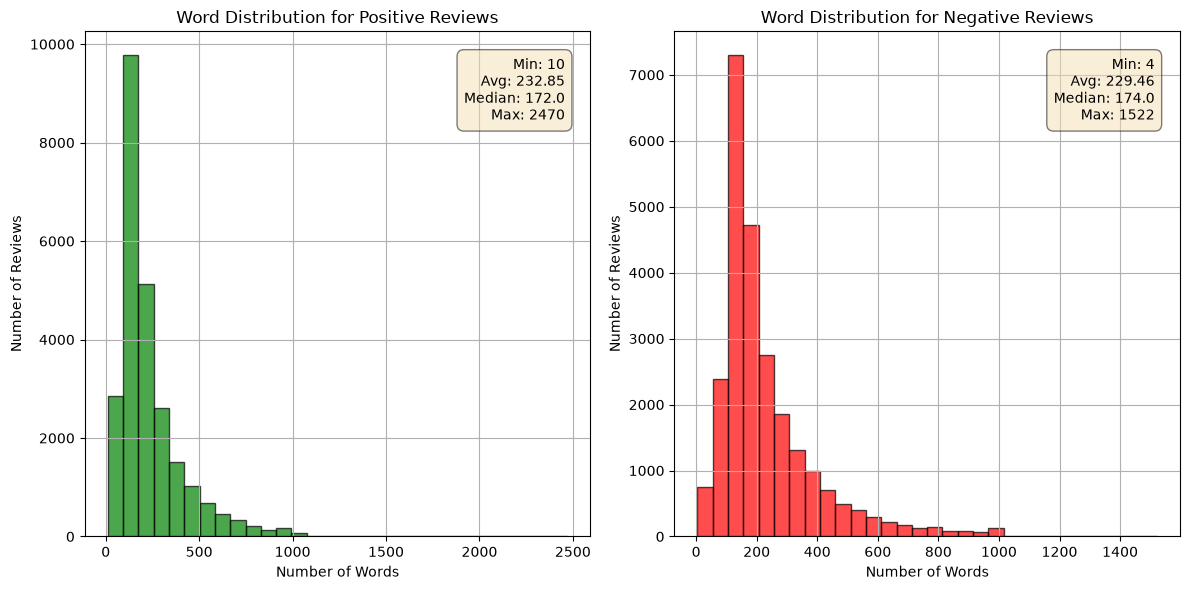

In [22]:
plot_review_length_by_sentiment(df)

In [23]:
def tokenize_reviews(x_train, x_val, x_test):
    vectorizer = CountVectorizer(max_features=1000, stop_words="english", token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')
    vectorizer.fit(x_train)
    vocab = {w:i + 1 for w, i in vectorizer.vocabulary_.items()}
    analyzer = vectorizer.build_analyzer()
    def vectorize_reviews(reviews):
        return [[vocab[token] for token in analyzer(review) if token in vocab] for review in reviews]
    
    _x_train = vectorize_reviews(x_train)
    _x_val = vectorize_reviews(x_val)
    _x_test = vectorize_reviews(x_test)

    return _x_train, _x_val, _x_test, vocab
    

In [24]:
x_train, x_val, x_test, vocab = tokenize_reviews(x_train, x_val, x_test)

In [25]:
def plot_review_length_distribution(tokenized_reviews):
    review_lengths = np.array([len(review) for review in tokenized_reviews])
    
    min_length = review_lengths.min()
    avg_length = review_lengths.mean()
    median_length = np.median(review_lengths)
    max_length = review_lengths.max()
    
    plt.figure(figsize=(10, 6))
    plt.hist(review_lengths, bins=30, color='blue', edgecolor='black', alpha=0.7)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    stats_text = f'Min Length: {min_length}\nAverage Length: {avg_length:.2f}\nMedian Length: {median_length}\nMax Length: {max_length}'
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, 
             verticalalignment='top', horizontalalignment='right', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))
             
    plt.savefig('review_length_after_tokenization.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

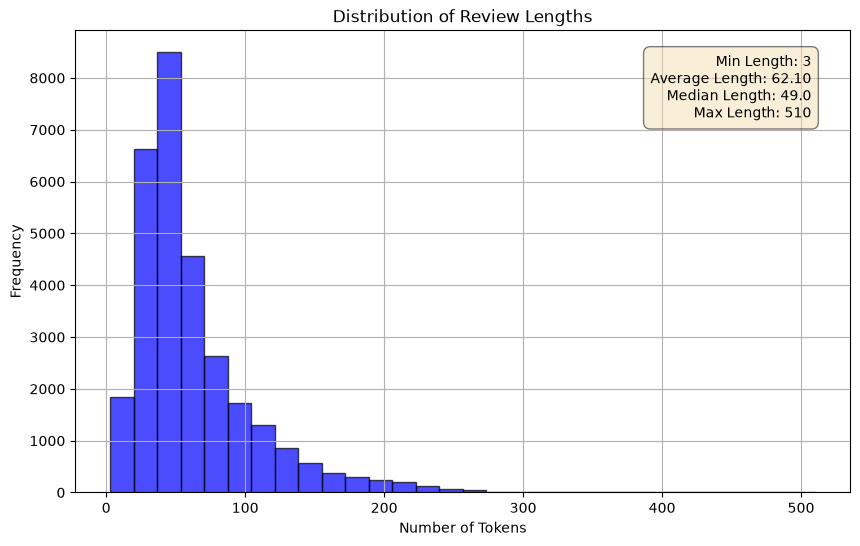

In [26]:
plot_review_length_distribution(x_train)

In [27]:
from torch.utils.data import TensorDataset, DataLoader
import torch
def padding_(reviews, max_seq):
    features = np.zeros((len(reviews), max_seq), dtype=int)
    for i, review in enumerate(reviews):
        if len(review) != 0:
            features[i, -len(review):] = np.array(review)[:max_seq]
    return np.array(features)

train_data = TensorDataset(torch.tensor(padding_(x_train, 500), dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
valid_data = TensorDataset(torch.tensor(padding_(x_val, 500), dtype=torch.long), torch.tensor(y_val, dtype=torch.long))
test_data  = TensorDataset(torch.tensor(padding_(x_test, 500), dtype=torch.long), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_data, shuffle=True, batch_size=50)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=50)
test_loader  = DataLoader(test_data, shuffle=True, batch_size=50)


In [28]:
class SentimentRNN(nn.Module):
    def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, output_dim, drop_prob):
        super().__init__()
        self.no_layers = no_layers
        self.hidden = hidden_dim
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, hidden_dim, no_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x, hidden):
        embeds = self.embedding(x)
        _, hidden = self.rnn(embeds, hidden)
        
        out = self.dropout(hidden[-1])
        out = self.fc(out)
        return torch.sigmoid(out).squeeze(-1), hidden
    
    def init_hidden(self, batch_size):
        device = next(self.parameters()).device
        return torch.zeros((self.no_layers, batch_size, self.hidden), device=device)

In [29]:
no_layers = 3
vocab_size = len(vocab) + 1
embedding_dim = 300
output_dim = 1
hidden_dim = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SentimentRNN(no_layers, vocab_size, hidden_dim, embedding_dim, output_dim, drop_prob=0.5).to(device)
model = torch.compile(model)

In [30]:
model

OptimizedModule(
  (_orig_mod): SentimentRNN(
    (embedding): Embedding(1001, 300)
    (rnn): GRU(300, 256, num_layers=3, batch_first=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [31]:
x = torch.randint(0, vocab_size, (1, 50)).to(device)
h = model.init_hidden(1)

# 1. Get predictions with current weights
out_before, _ = model(x, h)

# 2. Scramble fc weights
model.fc.weight.data.normal_()
model.fc.bias.data.zero_()

# 3. Get predictions again
out_after, _ = model(x, h)

print("Outputs match exactly:", torch.equal(out_before, out_after))

Outputs match exactly: False


In [32]:
model.fc.weight.data.zero_()
model.fc.bias.data.zero_()

out, _ = model(x, h)
print("All outputs are 0.5:", torch.all(out == 0.5).item())

All outputs are 0.5: True


In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

: 

In [ ]:
# Convert to tensors once upfront to avoid redundant overhead
x_train_tsne = torch.tensor(padding_(x_train, 500)[:1000], dtype=torch.long)
y_train_tsne = np.array(y_train[:1000]) 

def plot_embeddings(x_train, y_train, model, device, batch_size=50):
    model.eval()  
    embeddings_list = []

    # CHANGE: Removed TensorDataset and y_train; DataLoader can iterate a single tensor directly
    train_loader = torch.utils.data.DataLoader(x_train, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for x_batch in train_loader:
            x_batch = x_batch.to(device)
            hidden = model.init_hidden(x_batch.size(0))
            
            # CHANGE: Eliminated contiguous().view() and dropout (no-op in eval). 
            # nn.Linear natively handles 3D tensors: (batch, seq, hidden) -> (batch, seq, 1)
            embeds = model.embedding(x_batch)
            rnn_out, _ = model.rnn(embeds, hidden)
            linear_output = model.fc(rnn_out).squeeze(-1) # Outputs clean shape: (batch_size, 500)
            
            embeddings_list.append(linear_output.cpu())

    # CHANGE: Concatenate and convert directly to NumPy, skipping the unnecessary .view(-1, 500)
    all_embeddings = torch.cat(embeddings_list, dim=0).numpy()

    # CHANGE: Added n_jobs=-1 to use all CPU cores for significantly faster t-SNE processing
    tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
    embeddings_2d = tsne.fit_transform(all_embeddings) 

    df = pd.DataFrame(data=embeddings_2d, columns=['TSNE-1', 'TSNE-2'])
    df['label'] = y_train  
    custom_palette = {0: 'green', 1: 'red'}

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='TSNE-1', y='TSNE-2', hue='label', palette=custom_palette , s=60, alpha=0.6)
    plt.title('2D t-SNE Visualization of Sentence Embeddings')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc=2)  
    plt.savefig('tsne_model_untrained_projection.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

plot_embeddings(x_train_tsne, y_train_tsne, model, device, batch_size=50)